# task #3.2 randomized response for binary data
**based on**: Morris Chang, Di Zhuang, G. Dumindu Samaraweera - *Privacy-Preserving Machine Learning* (2023, Manning)

**dataset**: the titanic test file `aveshjadon/ai-impact-on-students`.

## how it works
randomized response (check previous notebook) only handles yes/no questions. direct encoding handles a
categorical question with `d` possible answers (here: a student's `primary_use_case`
for genai, which has 5 categories). it has three steps:

1. **encoding** — map each category to its index in a sorted domain.
2. **perturbation** — each person keeps their true answer with probability
   `p = e^eps / (d - 1 + e^eps)`, or reports one of the other `d-1` values with
   probability `q = (1 - p) / (d - 1)`. small epsilon -> p close to q -> more noise,
   more privacy. large epsilon -> p close to 1 -> little noise, less privacy.
3. **aggregation & estimation** — the raw perturbed counts are biased, so we correct
   each count `c_i` with `E_i = (c_i - n*q) / (p - q)` and clamp to a minimum of 1.

## import and understand dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")
print("path to dataset files:", path)

Using Colab cache for faster access to the 'ai-impact-on-students' dataset.
path to dataset files: /kaggle/input/ai-impact-on-students


In [ ]:
import os
files = os.listdir(path)
print("Files: ", files)

Files:  ['ai_student_impact_dataset (1).csv']


In [ ]:
import pandas as pd
df = pd.read_csv(os.path.join(path, files[0]))

In [ ]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [ ]:
for i in df.columns.tolist():
  print("\nCOLUMN NAME\n", i, "\nDATA TYPE\n", df[i].dtype, "\nUNIQUE VALUES\n", df[i].unique(), "\nVALUE COUNTS\n", df[i].value_counts())
  print("________________________________________________")


COLUMN NAME
 Student_ID 
DATA TYPE
 int64 
UNIQUE VALUES
 [100001 100002 100003 ... 149998 149999 150000] 
VALUE COUNTS
 Student_ID
149984    1
149983    1
149982    1
149981    1
149980    1
         ..
100005    1
100004    1
100003    1
100002    1
100001    1
Name: count, Length: 50000, dtype: int64
________________________________________________

COLUMN NAME
 Major_Category 
DATA TYPE
 object 
UNIQUE VALUES
 ['Humanities' 'Medical' 'Business' 'STEM' 'Arts'] 
VALUE COUNTS
 Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64
________________________________________________

COLUMN NAME
 Year_of_Study 
DATA TYPE
 object 
UNIQUE VALUES
 ['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate'] 
VALUE COUNTS
 Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64
________________________________________________

COLUMN NA

In [ ]:
print(df["Primary_Use_Case"].value_counts())

Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64


## listing 4.6 - encoding
direct encoding has no real transform: a value's encoded form is just its index in the domain.

In [ ]:
use_case = df["Primary_Use_Case"].dropna()

domain = df["Primary_Use_Case"].dropna().unique()
domain.sort()
domain
# 5 categories -> d = 5

array(['Copywriting/Drafting', 'Debugging/Troubleshooting',
       'Direct_Answer_Generation', 'Ideation', 'Summarizing_Reading'],
      dtype=object)

In [ ]:
import numpy as np

def encoding(answer):
    return int(np.where(domain == answer)[0][0])

for c in domain:
    print(encoding(c), c)

0 Copywriting/Drafting
1 Debugging/Troubleshooting
2 Direct_Answer_Generation
3 Ideation
4 Summarizing_Reading


## listing 4.7 - perturbation
each person reports their true value with probability `p`, otherwise reports one of the remaining `d-1` values (probability `q` each). this is what each individual sends to the aggregator, so the raw data is already privatized on the client side.

small epsilon (e.g. 0.1) -> noisy, strong privacy.
large epsilon (e.g. 5.0) -> accurate, weak privacy.

In [ ]:
import math

In [ ]:
def perturbation(encoded_ans, epsilon=5.0):
    d = len(domain) # num of classes
    p = pow(math.e, epsilon) / (d - 1 + pow(math.e, epsilon))
    q = (1.0 - p) / (d - 1.0)
    s1 = np.random.random()
    if s1 <= p:
        return domain[encoded_ans] # return true value with prob p
    else:
        s2 = np.random.randint(0, d - 1)
        return domain[(encoded_ans + s2) % d] # else a random other value

# show p and q for a couple of budgets
for eps in [5.0, 1.0, 0.1]:
    d = len(domain)
    p = pow(math.e, eps) / (d - 1 + pow(math.e, eps))
    q = (1.0 - p) / (d - 1.0)
    print("epsilon = {:>4} -> p = {:.4f}, q = {:.4f}".format(eps, p, q))

epsilon =  5.0 -> p = 0.9738, q = 0.0066
epsilon =  1.0 -> p = 0.4046, q = 0.1488
epsilon =  0.1 -> p = 0.2165, q = 0.1959


## listing 4.8 - results after perturbation
apply the perturbation to every individual and count. these raw counts are what a naive aggregator would see — they are noticeably off from the truth.

In [ ]:
perturbed_answers = pd.DataFrame([perturbation(encoding(i), epsilon=5.0) for i in use_case])
print("Perturbed values")
print(perturbed_answers.value_counts())
print("__________________________________")
print("True values")
print(df["Primary_Use_Case"].value_counts())

Perturbed values
0                        
Debugging/Troubleshooting    12240
Copywriting/Drafting         11927
Ideation                     10706
Summarizing_Reading           8673
Direct_Answer_Generation      6454
Name: count, dtype: int64
__________________________________
True values
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64


## listing 4.10 — aggregation and estimation
the aggregator removes the expected noise from each raw count:
`E_i = (c_i - n*q) / (p - q)`. this debiases the histogram and recovers counts close to the truth even though every individual answer stayed noisy.

In [ ]:
def aggregation_and_estimation(answers, epsilon=5.0):
    n = len(answers)
    d = len(domain)
    p = pow(math.e, epsilon) / (d - 1 + pow(math.e, epsilon))
    q = (1.0 - p) / (d - 1.0)
    aggregator = answers.value_counts().sort_index()
    return [max(int((i - n * q) / (p - q)), 1) for i in aggregator]

estimated_answers = aggregation_and_estimation(perturbed_answers, epsilon=5.0)
list(zip(domain, estimated_answers))

[('Copywriting/Drafting', 11992),
 ('Debugging/Troubleshooting', 12315),
 ('Direct_Answer_Generation', 6333),
 ('Ideation', 10729),
 ('Summarizing_Reading', 8627)]

## comparing several privacy budgets
now we run the full pipeline (perturb -> estimate) for several epsilon values and compare the raw perturbed counts and the corrected estimates against the truth. this shows the privacy/accuracy trade-off directly.

In [ ]:
actual_counts = use_case.value_counts().sort_index()

In [ ]:
def run_pipeline(epsilon):
    perturbed = pd.DataFrame([perturbation(encoding(i), epsilon=epsilon)
                              for i in use_case])
    perturbed_counts = perturbed.value_counts().sort_index()
    # align to full domain (a category might be missing at very low epsilon)
    perturbed_counts = perturbed_counts.reindex(domain, fill_value=0)
    estimated = aggregation_and_estimation(perturbed, epsilon=epsilon)
    return perturbed_counts.values, np.array(estimated)

budgets = [0.1, 0.5, 1.0, 5.0]
actual = actual_counts.reindex(domain).values

results = {}
for eps in budgets:
    pert, est = run_pipeline(eps)
    results[eps] = (pert, est)

# build a comparison table
table = pd.DataFrame({"category": domain, "actual": actual})
for eps in budgets:
    pert, est = results[eps]
    table["perturbed_eps{}".format(eps)] = pert
    table["estimated_eps{}".format(eps)] = est
table

,category,actual,perturbed_eps0.1,estimated_eps0.1,perturbed_eps0.5,estimated_eps0.5,perturbed_eps1.0,estimated_eps1.0,perturbed_eps5.0,estimated_eps5.0
0,Copywriting/Drafting,12011,0,4563,0,10835,0,11747,0,12025
1,Debugging/Troubleshooting,12295,0,66502,0,22294,0,16072,0,12366
2,Direct_Answer_Generation,6340,0,1,0,1,0,3556,0,6284
3,Ideation,10721,0,31018,0,14606,0,12001,0,10722
4,Summarizing_Reading,8633,0,1,0,2337,0,6621,0,8601


In [ ]:
print("mean absolute error (estimated vs actual) by privacy budget:")
for eps in budgets:
    _, est = results[eps]
    mae = np.mean(np.abs(est - actual))
    print("  epsilon = {:>4} -> MAE = {:8.1f}".format(eps, mae))
# larger epsilon -> smaller error (less privacy), smaller epsilon -> larger error (more privacy)

mean absolute error (estimated vs actual) by privacy budget:
  epsilon =  0.1 -> MAE =  19384.6
  epsilon =  0.5 -> MAE =   5539.0
  epsilon =  1.0 -> MAE =   2023.4
  epsilon =  5.0 -> MAE =     34.8


In [ ]:
import matplotlib.pyplot as plt

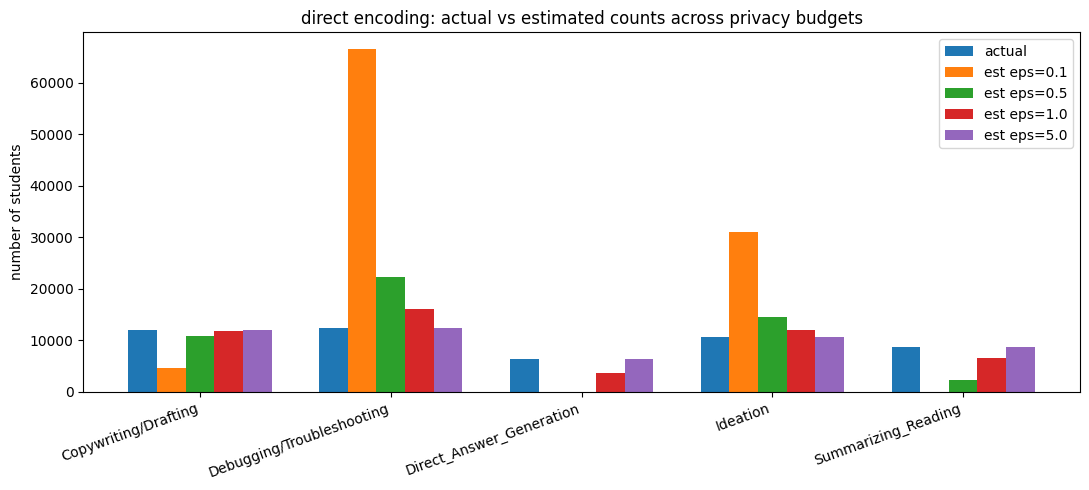

In [ ]:
# actual vs estimated for each budget
x = np.arange(len(domain))
w = 0.15
plt.figure(figsize=(11, 5))
plt.bar(x - 2*w, actual, w, label="actual")
for k, eps in enumerate(budgets):
    _, est = results[eps]
    plt.bar(x + (k-1)*w, est, w, label="est eps={}".format(eps))
plt.xticks(x, domain, rotation=20, ha="right")
plt.ylabel("number of students")
plt.title("direct encoding: actual vs estimated counts across privacy budgets")
plt.legend()
plt.tight_layout()
plt.show()

## discussion on the results

**before correction (raw perturbed counts):** at high epsilon the perturbed counts are already fairly close, but at low epsilon (0.1) the noise dominates and pushes every category toward roughly `n/d` (a flat histogram), because almost everyone is reporting a random category. the raw counts are systematically biased.

**after correction (listing 4.10 estimates):** the `(c_i - n*q)/(p - q)` formula removes that bias. at **epsilon = 5.0** the estimates land very close to the true counts (low MAE, weak privacy). as epsilon drops to **1.0**, then **0.5**, then **0.1**, the estimates get progressively noisier and the MAE grows — but the histogram shape is still recoverable on average, because the estimator stays unbiased even when its variance is large.

**the trade-off:** small epsilon = strong per-person privacy but noisy aggregates; large epsilon = accurate aggregates but weaker privacy. crucially, in every case the individual answers leaving each student's device were already perturbed — the server never sees a true value, yet can still estimate the population distribution.
